# Cell 0 — Setup

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Kiểm tra file
import os
REVIEW_PATH = '/content/drive/MyDrive/DA.My/Data/Cell_Phones_and_Accessories.csv'
META_PATH   = '/content/drive/MyDrive/DA.My/Data/meta_Cell_Phones_and_Accessories.jsonl'

print(f'Review file exists: {os.path.exists(REVIEW_PATH)}')
print(f'Meta file exists  : {os.path.exists(META_PATH)}')

Mounted at /content/drive
Review file exists: True
Meta file exists  : True


# Cell 1 Setup + tự động tìm file thật

In [2]:
import json, gc, subprocess, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

ROOT = Path('/content/drive/MyDrive/DA.My')
RAW  = ROOT / 'Data'
EDA  = ROOT / 'eda'
EDA.mkdir(parents=True, exist_ok=True)

def find_file(folder: Path, exts):
    """Tìm file thật bên trong folder (đệ quy), match đuôi."""
    if folder.is_file():
        return folder
    for ext in exts:
        files = list(folder.rglob(f'*{ext}'))
        files = [f for f in files if f.is_file() and f.stat().st_size > 0]
        if files:
            return max(files, key=lambda f: f.stat().st_size)  # file lớn nhất
    return None

CSV_PATH  = find_file(RAW / 'Cell_Phones_and_Accessories.csv',      ['.csv'])
META_PATH = find_file(RAW / 'meta_Cell_Phones_and_Accessories.jsonl',['.jsonl', '.json'])

assert CSV_PATH  and CSV_PATH.exists(),  'CSV không tìm thấy'
assert META_PATH and META_PATH.exists(), 'META không tìm thấy'

print('CSV  :', CSV_PATH,  '| MB:', round(CSV_PATH.stat().st_size/1e6, 2))
print('META :', META_PATH, '| MB:', round(META_PATH.stat().st_size/1e6, 2))
print('EDA out:', EDA)

CSV  : /content/drive/MyDrive/DA.My/Data/Cell_Phones_and_Accessories.csv/Cell_Phones_and_Accessories.csv | MB: 159.67
META : /content/drive/MyDrive/DA.My/Data/meta_Cell_Phones_and_Accessories.jsonl/meta_Cell_Phones_and_Accessories.jsonl | MB: 4015.16
EDA out: /content/drive/MyDrive/DA.My/eda


# Cell 2 — Peek schema CSV

In [3]:
# Đọc 5 dòng đầu để xem schema thực
df_peek = pd.read_csv(CSV_PATH, nrows=5)
print('Columns:', df_peek.columns.tolist())
print('Dtypes :\n', df_peek.dtypes)
print('\n--- First 5 rows ---')
df_peek

Columns: ['user_id', 'parent_asin', 'rating', 'timestamp']
Dtypes :
 user_id         object
parent_asin     object
rating         float64
timestamp        int64
dtype: object

--- First 5 rows ---


,user_id,parent_asin,rating,timestamp
0,AHOEIYJJHZ7ITX75BOFQYNXVVJQQ,B08T95LBMF,5.0,1620264886453
1,AHOEIYJJHZ7ITX75BOFQYNXVVJQQ,B0921JG3RC,5.0,1643906098659
2,AHOEIYJJHZ7ITX75BOFQYNXVVJQQ,B0BQ2H896H,5.0,1643906617488
3,AHOEIYJJHZ7ITX75BOFQYNXVVJQQ,B0BST1WHNG,5.0,1659508145365
4,AHOEIYJJHZ7ITX75BOFQYNXVVJQQ,B08M636GG3,5.0,1677845517223


#  Cell 3 — Load full CSV

In [4]:
dtypes = {
    'user_id'    : 'string',
    'parent_asin': 'string',
    'rating'     : 'float32',
    'timestamp'  : 'int64',
}

df = pd.read_csv(CSV_PATH, dtype=dtypes)
df = df.rename(columns={'parent_asin': 'asin'})

print('Shape:', df.shape)
print('\nMemory usage:')
df.info(memory_usage='deep')
print('\nHead:')
df.head()

Shape: (2752785, 4)

Memory usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2752785 entries, 0 to 2752784
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   user_id    string 
 1   asin       string 
 2   rating     float32
 3   timestamp  int64  
dtypes: float32(1), int64(1), string(2)
memory usage: 388.5 MB

Head:


,user_id,asin,rating,timestamp
0,AHOEIYJJHZ7ITX75BOFQYNXVVJQQ,B08T95LBMF,5.0,1620264886453
1,AHOEIYJJHZ7ITX75BOFQYNXVVJQQ,B0921JG3RC,5.0,1643906098659
2,AHOEIYJJHZ7ITX75BOFQYNXVVJQQ,B0BQ2H896H,5.0,1643906617488
3,AHOEIYJJHZ7ITX75BOFQYNXVVJQQ,B0BST1WHNG,5.0,1659508145365
4,AHOEIYJJHZ7ITX75BOFQYNXVVJQQ,B08M636GG3,5.0,1677845517223


# Cell 4 — Quality check

In [5]:
print('=== MISSING (%) ===')
print((df.isna().mean()*100).round(4))

print('\n=== DUPLICATES ===')
print('Full row duplicates       :', df.duplicated().sum())
print('(user, asin) duplicates   :', df.duplicated(['user_id','asin']).sum())

print('\n=== RATING ===')
print(df['rating'].describe())
print('\nRating value counts:')
print(df['rating'].value_counts().sort_index())

print('\n=== TIMESTAMP ===')
# timestamp là ms → chia 1000
ts_sec = (df['timestamp'] // 1000).astype('int64')
ts_dt = pd.to_datetime(ts_sec, unit='s')
print('Min:', ts_dt.min())
print('Max:', ts_dt.max())
print('Range:', (ts_dt.max() - ts_dt.min()).days, 'days')

=== MISSING (%) ===
user_id      0.0
asin         0.0
rating       0.0
timestamp    0.0
dtype: float64

=== DUPLICATES ===
Full row duplicates       : 0
(user, asin) duplicates   : 0

=== RATING ===
count    2.752785e+06
mean     4.218169e+00
std      1.268466e+00
min      1.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

Rating value counts:
rating
1.0     233527
2.0     139612
3.0     214488
4.0     370293
5.0    1794865
Name: count, dtype: int64

=== TIMESTAMP ===
Min: 2003-05-07 18:52:41
Max: 2023-09-06 00:18:04
Range: 7426 days


# Cell 5 Quy mô + Distribution theo năm

=== RAW ===
Users        :      380,999
Items        :      111,480
Interactions :    2,752,785
Sparsity     : 99.993519%
Avg/user     : 7.23
Avg/item     : 24.69

=== INTERACTIONS BY YEAR ===
 year  interactions  users  items  cum_pct   pct
 2003             7      7      3     0.00  0.00
 2004            33     33     12     0.00  0.00
 2005           107     99     26     0.01  0.00
 2006           131    123     53     0.01  0.00
 2007           234    220     95     0.02  0.01
 2008           415    397    162     0.03  0.02
 2009          1001    894    321     0.07  0.04
 2010          3080   2666    891     0.18  0.11
 2011          8983   7067   2211     0.51  0.33
 2012         26223  17619   5481     1.46  0.95
 2013         77679  43243  10315     4.28  2.82
 2014        140956  71218  17347     9.40  5.12
 2015        229369 105813  24993    17.74  8.33
 2016        264426 122697  31080    27.34  9.61
 2017        269068 133090  32780    37.12  9.77
 2018        288873 143

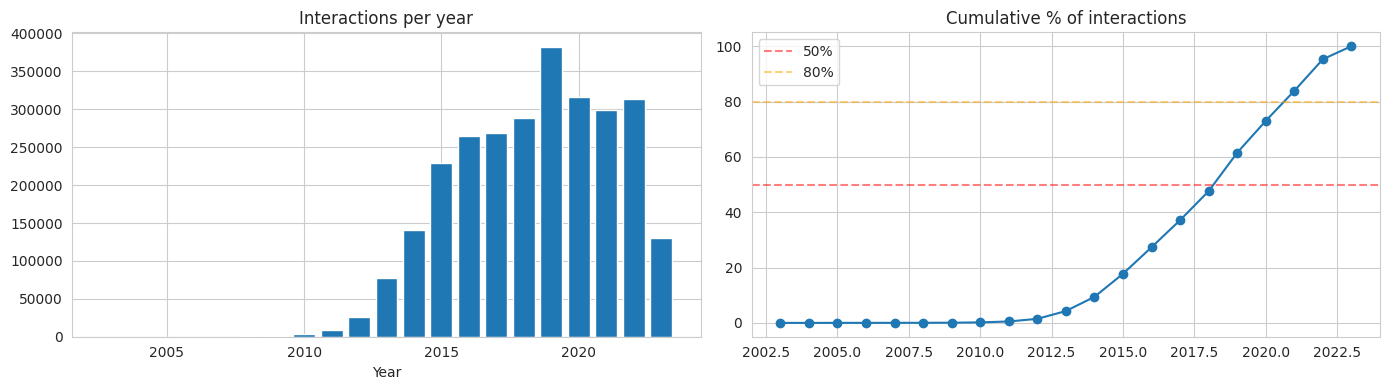

In [6]:
nu = df['user_id'].nunique()
ni = df['asin'].nunique()
n  = len(df)

print(f'=== RAW ===')
print(f'Users        : {nu:>12,}')
print(f'Items        : {ni:>12,}')
print(f'Interactions : {n:>12,}')
print(f'Sparsity     : {1 - n/(nu*ni):.6%}')
print(f'Avg/user     : {n/nu:.2f}')
print(f'Avg/item     : {n/ni:.2f}')

# Phân phối theo năm
df['year'] = pd.to_datetime(df['timestamp']//1000, unit='s').dt.year
year_stats = df.groupby('year').agg(
    interactions=('rating','count'),
    users=('user_id','nunique'),
    items=('asin','nunique')
).reset_index()
year_stats['cum_pct'] = (year_stats['interactions'].cumsum() / n * 100).round(2)
year_stats['pct'] = (year_stats['interactions'] / n * 100).round(2)

print('\n=== INTERACTIONS BY YEAR ===')
print(year_stats.to_string(index=False))

# Plot
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(year_stats['year'], year_stats['interactions'])
ax[0].set_title('Interactions per year'); ax[0].set_xlabel('Year')
ax[1].plot(year_stats['year'], year_stats['cum_pct'], marker='o')
ax[1].axhline(50, color='r', ls='--', alpha=0.5, label='50%')
ax[1].axhline(80, color='orange', ls='--', alpha=0.5, label='80%')
ax[1].set_title('Cumulative % of interactions'); ax[1].legend()
plt.tight_layout(); plt.show()

# Cell 6 — Cắt data từ 2018 + xem lại sparsity

In [7]:
CUTOFF_YEAR = 2018

df_f = df[df['year'] >= CUTOFF_YEAR].copy()

nu_f = df_f['user_id'].nunique()
ni_f = df_f['asin'].nunique()
n_f  = len(df_f)

print(f'=== AFTER CUTOFF {CUTOFF_YEAR}+ ===')
print(f'Users        : {nu_f:>12,}  ({nu_f/nu*100:.1f}% giữ lại)')
print(f'Items        : {ni_f:>12,}  ({ni_f/ni*100:.1f}% giữ lại)')
print(f'Interactions : {n_f:>12,}  ({n_f/n*100:.1f}% giữ lại)')
print(f'Sparsity     : {1 - n_f/(nu_f*ni_f):.6%}')
print(f'Avg/user     : {n_f/nu_f:.2f}')
print(f'Avg/item     : {n_f/ni_f:.2f}')

# So sánh nhanh các cutoff khác
print('\n=== COMPARE CUTOFFS ===')
for c in [2018, 2019, 2020]:
    sub = df[df['year'] >= c]
    print(f'>={c}: {len(sub):>9,} inter | {sub.user_id.nunique():>7,} users | {sub.asin.nunique():>6,} items')

=== AFTER CUTOFF 2018+ ===
Users        :      341,413  (89.6% giữ lại)
Items        :       90,248  (81.0% giữ lại)
Interactions :    1,731,073  (62.9% giữ lại)
Sparsity     : 99.994382%
Avg/user     : 5.07
Avg/item     : 19.18

=== COMPARE CUTOFFS ===
>=2018: 1,731,073 inter | 341,413 users | 90,248 items
>=2019: 1,442,200 inter | 320,261 users | 81,322 items
>=2020: 1,059,797 inter | 282,516 users | 67,656 items


# Cell 7 — Phân phối user/item + Cold-start severity

=== USER INTERACTION COUNTS ===
count    341413.00
mean          5.07
std           3.74
min           1.00
50%           5.00
75%           6.00
90%           8.00
95%          11.00
99%          18.00
max         249.00
dtype: float64

=== ITEM INTERACTION COUNTS ===
count    90248.00
mean        19.18
std         58.57
min          1.00
50%          8.00
75%         16.00
90%         36.00
95%         64.00
99%        197.53
max       3758.00
dtype: float64

=== COLD-START SEVERITY ===
   k |    % users < k |    % items < k
------------------------------------------
   1 |          0.00% |          0.00%
   2 |          9.12% |          9.31%
   3 |         19.61% |         13.95%
   5 |         44.92% |         19.82%
  10 |         93.18% |         58.02%


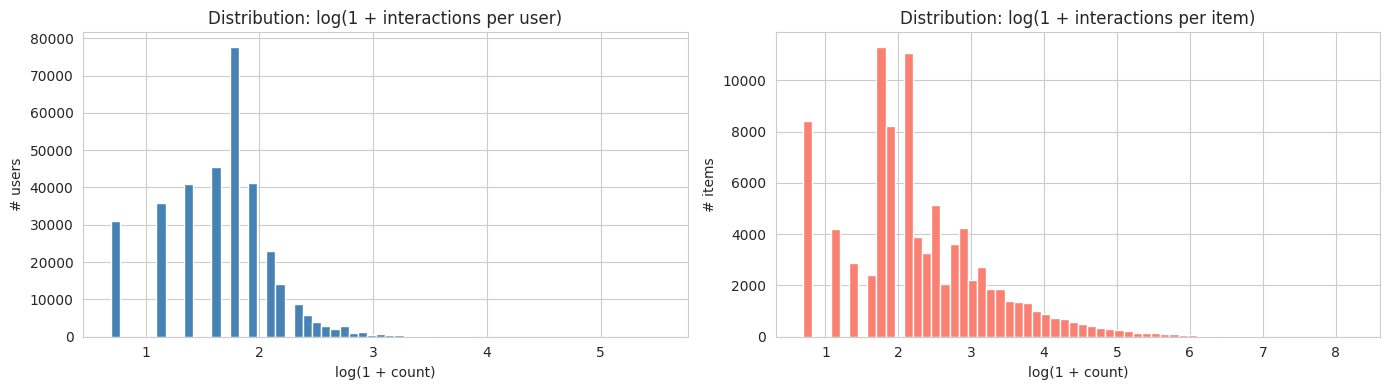

In [8]:
u_cnt = df_f.groupby('user_id').size()
i_cnt = df_f.groupby('asin').size()

print('=== USER INTERACTION COUNTS ===')
print(u_cnt.describe(percentiles=[.5, .75, .9, .95, .99]).round(2))

print('\n=== ITEM INTERACTION COUNTS ===')
print(i_cnt.describe(percentiles=[.5, .75, .9, .95, .99]).round(2))

print('\n=== COLD-START SEVERITY ===')
print(f'{"k":>4} | {"% users < k":>14} | {"% items < k":>14}')
print('-' * 42)
for k in [1, 2, 3, 5, 10]:
    pu = (u_cnt < k).mean() * 100
    pi = (i_cnt < k).mean() * 100
    print(f'{k:>4} | {pu:>13.2f}% | {pi:>13.2f}%')

# Biểu đồ log-scale histogram
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(np.log1p(u_cnt), bins=60, color='steelblue', edgecolor='white')
ax[0].set_title('Distribution: log(1 + interactions per user)')
ax[0].set_xlabel('log(1 + count)'); ax[0].set_ylabel('# users')

ax[1].hist(np.log1p(i_cnt), bins=60, color='salmon', edgecolor='white')
ax[1].set_title('Distribution: log(1 + interactions per item)')
ax[1].set_xlabel('log(1 + count)'); ax[1].set_ylabel('# items')
plt.tight_layout(); plt.show()

# Cell 8 — K-core filter lặp đến hội tụ

In [9]:
def kcore_iterative(df_in, ku=5, ki=5, max_iter=20):
    """Lặp filter user và item đến khi không còn ai dưới ngưỡng."""
    df = df_in.copy()
    for it in range(1, max_iter+1):
        n0 = len(df)
        # User
        uc = df.groupby('user_id').size()
        df = df[df['user_id'].isin(uc[uc >= ku].index)]
        # Item
        ic = df.groupby('asin').size()
        df = df[df['asin'].isin(ic[ic >= ki].index)]
        print(f'Iter {it:2d}: {len(df):>9,} interactions | {df.user_id.nunique():>7,} users | {df.asin.nunique():>6,} items')
        if len(df) == n0:
            print(f'✓ Converged at iter {it}')
            break
    return df.reset_index(drop=True)

df_kc = kcore_iterative(df_f, ku=5, ki=5)

# So sánh trước/sau
nu_kc = df_kc['user_id'].nunique()
ni_kc = df_kc['asin'].nunique()
n_kc  = len(df_kc)

print('\n=== AFTER K-CORE ===')
print(f'Users        : {nu_kc:>9,} ({nu_kc/nu_f*100:.1f}% giữ lại, {nu_kc/nu*100:.1f}% so với raw)')
print(f'Items        : {ni_kc:>9,} ({ni_kc/ni_f*100:.1f}% giữ lại, {ni_kc/ni*100:.1f}% so với raw)')
print(f'Interactions : {n_kc:>9,} ({n_kc/n_f*100:.1f}% giữ lại, {n_kc/n*100:.1f}% so với raw)')
print(f'Sparsity     : {1 - n_kc/(nu_kc*ni_kc):.6%}')
print(f'Avg/user     : {n_kc/nu_kc:.2f}')
print(f'Avg/item     : {n_kc/ni_kc:.2f}')

Iter  1: 1,250,425 interactions | 188,036 users | 58,849 items
Iter  2: 1,157,332 interactions | 167,102 users | 55,248 items
Iter  3: 1,136,125 interactions | 162,626 users | 54,373 items
Iter  4: 1,130,865 interactions | 161,502 users | 54,177 items
Iter  5: 1,129,673 interactions | 161,247 users | 54,134 items
Iter  6: 1,129,377 interactions | 161,191 users | 54,116 items
Iter  7: 1,129,285 interactions | 161,173 users | 54,111 items
Iter  8: 1,129,265 interactions | 161,169 users | 54,110 items
Iter  9: 1,129,261 interactions | 161,168 users | 54,110 items
Iter 10: 1,129,261 interactions | 161,168 users | 54,110 items
✓ Converged at iter 10

=== AFTER K-CORE ===
Users        :   161,168 (47.2% giữ lại, 42.3% so với raw)
Items        :    54,110 (60.0% giữ lại, 48.5% so với raw)
Interactions : 1,129,261 (65.2% giữ lại, 41.0% so với raw)
Sparsity     : 99.987051%
Avg/user     : 7.01
Avg/item     : 20.87


# Cell 9 — Peek metadata JSONL

In [10]:
# Xem schema metadata: đọc 5 dòng đầu, KHÔNG load full (file 4GB)
def peek_jsonl(path, n=5):
    samples = []
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= n: break
            samples.append(json.loads(line))
    return samples

samples = peek_jsonl(META_PATH, n=3)

# In 1 record để xem cấu trúc
print('=== SAMPLE RECORD KEYS ===')
print(list(samples[0].keys()))
print('\n=== SAMPLE RECORD (full) ===')
print(json.dumps(samples[0], indent=2, ensure_ascii=False)[:2000])

=== SAMPLE RECORD KEYS ===
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']

=== SAMPLE RECORD (full) ===
{
  "main_category": "Cell Phones & Accessories",
  "title": "ARAREE Slim Diary Cell Phone Case for Samsung Galaxy Note 5 - Retail Packaging - Coral Pink",
  "average_rating": 3.8,
  "rating_number": 5,
  "features": [
    "Genuine Cow leather with 6 different colors",
    "3 Pockets for ID, Cards and receipts",
    "The inside skin is made of microsuede, polycarbonate",
    "It doesn't have magnets The inner PC case color is gold",
    "Made in Korea"
  ],
  "description": [
    "JUST LOOK, You can tell the difference. Make everyday more convenient, it is slim but has big rooms. If you are looking for a rich and luxurious appearance, look no further. These double shoulders are the perfect leather for creating attractive finished belts, straps and

# Cell 10 — Stream load metadata (chỉ giữ items sau k-core)

In [11]:
# Tập items cần giữ (sau k-core)
items_keep = set(df_kc['asin'].unique())
print(f'Cần load metadata cho {len(items_keep):,} items')

def parse_record(d):
    asin = d.get('parent_asin')
    if asin not in items_keep:
        return None
    img = ''
    imgs = d.get('images') or []
    if imgs and isinstance(imgs, list):
        img = imgs[0].get('large') or imgs[0].get('thumb') or ''
    desc = d.get('description') or []
    feat = d.get('features') or []
    cats = d.get('categories') or []
    return {
        'asin'          : asin,
        'title'         : d.get('title') or '',
        'description'   : ' '.join(desc) if isinstance(desc, list) else str(desc or ''),
        'features'      : ' '.join(feat) if isinstance(feat, list) else str(feat or ''),
        'categories'    : ' > '.join(cats) if isinstance(cats, list) else str(cats or ''),
        'store'         : d.get('store') or '',
        'main_category' : d.get('main_category') or '',
        'price'         : d.get('price'),
        'avg_rating'    : d.get('average_rating'),
        'rating_number' : d.get('rating_number'),
        'image_url'     : img,
    }

rows = []
n_total, n_kept, n_error = 0, 0, 0
with open(META_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        n_total += 1
        try:
            d = json.loads(line)
            rec = parse_record(d)
            if rec:
                rows.append(rec)
                n_kept += 1
        except Exception:
            n_error += 1
        if n_total % 200000 == 0:
            print(f'  Scanned {n_total:>9,} | Kept {n_kept:>6,} | Errors {n_error}')

print(f'\n✓ Done. Total scanned: {n_total:,} | Kept: {n_kept:,} | Errors: {n_error}')

meta = pd.DataFrame(rows)
print(f'\nMeta shape: {meta.shape}')
print(f'Coverage: {len(meta)/len(items_keep)*100:.2f}% items có metadata')
print(f'Memory: {meta.memory_usage(deep=True).sum()/1e6:.1f} MB')
meta.head(3)

Cần load metadata cho 54,110 items
  Scanned   200,000 | Kept 18,269 | Errors 0
  Scanned   400,000 | Kept 29,181 | Errors 0
  Scanned   600,000 | Kept 37,495 | Errors 0
  Scanned   800,000 | Kept 44,789 | Errors 0
  Scanned 1,000,000 | Kept 51,658 | Errors 0
  Scanned 1,200,000 | Kept 54,106 | Errors 0

✓ Done. Total scanned: 1,288,490 | Kept: 54,110 | Errors: 0

Meta shape: (54110, 11)
Coverage: 100.00% items có metadata
Memory: 140.0 MB


,asin,title,description,features,categories,store,main_category,price,avg_rating,rating_number,image_url
0,B0BHY2CR5B,"iMangoo Galaxy S22 Case, for Samsung Galaxy S2...",,Compatibility: This Galaxy S22 case is only co...,"Cell Phones & Accessories > Cases, Holsters & ...",iMangoo,Cell Phones & Accessories,11.99,4.5,530,https://m.media-amazon.com/images/I/51nZu7lnhH...
1,B0B8ZBCCY6,WSKEN for Samsung Galaxy Z Fold 4 Camera Lens ...,,Compatibility: The aluminum alloy metal 9H tem...,Cell Phones & Accessories > Accessories > Main...,WSKEN,Cell Phones & Accessories,11.99,4.5,354,https://m.media-amazon.com/images/I/51eGiaTv8a...
2,B07YTYFBCT,[2 Pack] Camera Screen Protector for iPhone 11...,,【Cut precisely】Specially Designed for iPhone 1...,Cell Phones & Accessories > Accessories > Main...,SMAPP,Cell Phones & Accessories,None,3.7,807,https://m.media-amazon.com/images/I/41EPk6DwsE...


# Cell 11 — Phân tích chất lượng metadata

In [12]:
print('=== TEXT FIELD COVERAGE ===')
for col in ['title', 'description', 'features', 'categories', 'store']:
    s = meta[col].astype(str).str.len()
    non_empty = (s > 0).mean() * 100
    avg_len = s[s > 0].mean()
    print(f'{col:<14} | non-empty: {non_empty:>5.2f}% | avg len: {avg_len:>7.0f} chars')

print('\n=== PRICE & RATING ===')
print(f'Price non-null   : {meta["price"].notna().mean()*100:.2f}%')
print(f'Avg_rating non-null: {meta["avg_rating"].notna().mean()*100:.2f}%')
print(f'Image_url non-empty: {(meta["image_url"].str.len()>0).mean()*100:.2f}%')

print('\n=== STORE (BRAND) ===')
print(f'Unique stores: {meta["store"].nunique():,}')
print('\nTop 15 stores:')
print(meta['store'].value_counts().head(15))

print('\n=== MAIN CATEGORY ===')
print(meta['main_category'].value_counts().head(5))

# Tạo "text" tổng hợp cho TF-IDF (sẽ dùng ở B6 Content-based)
meta['text'] = (
    meta['title'].fillna('') + ' ' +
    meta['features'].fillna('') + ' ' +
    meta['description'].fillna('') + ' ' +
    meta['categories'].fillna('') + ' ' +
    meta['store'].fillna('')
).str.lower()

text_len = meta['text'].str.len()
print('\n=== COMBINED TEXT FOR TF-IDF ===')
print(f'Min len  : {text_len.min()}')
print(f'Avg len  : {text_len.mean():.0f}')
print(f'Max len  : {text_len.max()}')
print(f'Empty    : {(text_len == 0).sum()}')

=== TEXT FIELD COVERAGE ===
title          | non-empty: 100.00% | avg len:     162 chars
description    | non-empty: 28.24% | avg len:     811 chars
features       | non-empty: 86.92% | avg len:    1003 chars
categories     | non-empty: 95.12% | avg len:      75 chars
store          | non-empty: 99.87% | avg len:       7 chars

=== PRICE & RATING ===
Price non-null   : 58.72%
Avg_rating non-null: 100.00%
Image_url non-empty: 99.99%

=== STORE (BRAND) ===
Unique stores: 11,036

Top 15 stores:
store
Spigen          1339
OtterBox         938
Supershieldz     637
SAMSUNG          452
Caseology        394
ESR              368
Encased          366
TORRAS           356
SUPCASE          349
Poetic           348
Mr.Shield        340
BENTOBEN         327
Zizo             314
Speck            309
Ringke           304
Name: count, dtype: int64

=== MAIN CATEGORY ===
main_category
Cell Phones & Accessories    41723
All Electronics               6667
AMAZON FASHION                2248
Camera & Photo

# Cell 12 — Lưu artifacts EDA + summary

In [13]:
PROC = ROOT / 'processed'
PROC.mkdir(parents=True, exist_ok=True)

# Clean price: convert sang float, ký tự lạ → NaN
meta['price'] = pd.to_numeric(meta['price'], errors='coerce').astype('float32')

# Đảm bảo các cột text là string
for c in ['asin','title','description','features','categories','store','main_category','image_url','text']:
    meta[c] = meta[c].astype('string').fillna('')

# avg_rating, rating_number → numeric
meta['avg_rating']    = pd.to_numeric(meta['avg_rating'], errors='coerce').astype('float32')
meta['rating_number'] = pd.to_numeric(meta['rating_number'], errors='coerce').fillna(0).astype('int32')

print('Dtypes after clean:')
print(meta.dtypes)

# 1. Interactions
df_kc_save = df_kc[['user_id','asin','rating','timestamp']].copy()
df_kc_save.to_parquet(PROC / 'interactions_kcore.parquet', index=False)

# 2. Metadata
meta.to_parquet(PROC / 'meta_filtered.parquet', index=False)

# 3. Summary
summary = {
    'raw': {'users': int(nu), 'items': int(ni), 'interactions': int(n)},
    'after_cutoff_2018': {'users': int(nu_f), 'items': int(ni_f), 'interactions': int(n_f)},
    'after_kcore_5_5': {
        'users': int(nu_kc), 'items': int(ni_kc), 'interactions': int(n_kc),
        'sparsity': float(1 - n_kc/(nu_kc*ni_kc)),
        'avg_per_user': float(n_kc/nu_kc), 'avg_per_item': float(n_kc/ni_kc),
    },
    'preprocessing_decisions': {
        'time_cutoff': 2018, 'kcore_user': 5, 'kcore_item': 5,
    },
}
with open(EDA / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('\n✓ Saved:')
for p in [PROC/'interactions_kcore.parquet', PROC/'meta_filtered.parquet', EDA/'summary.json']:
    print(f'  {p.name:35s} {p.stat().st_size/1e6:>7.2f} MB')

print('\n' + '='*60)
print('  EDA HOÀN TẤT')
print('='*60)
print(f'  Users: {nu_kc:,} | Items: {ni_kc:,} | Interactions: {n_kc:,}')
print(f'  Sparsity: {(1-n_kc/(nu_kc*ni_kc))*100:.4f}%')
print('='*60)

Dtypes after clean:
asin             string[python]
title            string[python]
description      string[python]
features         string[python]
categories       string[python]
store            string[python]
main_category    string[python]
price                   float32
avg_rating              float32
rating_number             int32
image_url        string[python]
text             string[python]
dtype: object

✓ Saved:
  interactions_kcore.parquet            17.50 MB
  meta_filtered.parquet                 80.49 MB
  summary.json                           0.00 MB

  EDA HOÀN TẤT
  Users: 161,168 | Items: 54,110 | Interactions: 1,129,261
  Sparsity: 99.9871%


# Cell 13 — Preprocessing với 80/20 split

In [14]:
from scipy.sparse import csr_matrix, save_npz

# Reload guard
try: _ = df_kc.shape
except NameError:
    df_kc = pd.read_parquet(PROC / 'interactions_kcore.parquet')
    meta  = pd.read_parquet(PROC / 'meta_filtered.parquet')

# 1. ID mapping
users = df_kc['user_id'].unique()
items = df_kc['asin'].unique()
u2idx = {u:i for i,u in enumerate(users)}
i2idx = {a:i for i,a in enumerate(items)}
df_kc['u'] = df_kc['user_id'].map(u2idx).astype('int32')
df_kc['i'] = df_kc['asin'].map(i2idx).astype('int32')
n_users, n_items = len(users), len(items)

# 2. Recency-weighted score
ts_sec = (df_kc['timestamp'] // 1000).astype('int64')
t_max  = ts_sec.max()
days_ago = ((t_max - ts_sec) / 86400).astype('float32')
DECAY = 0.002
df_kc['score'] = (df_kc['rating'] * np.exp(-DECAY * days_ago)).astype('float32')
df_kc['ts']    = ts_sec

# 3. TEMPORAL 80/20 SPLIT — mỗi user giữ 20% interactions cuối làm test
print('Splitting 80/20 temporal per user...')
df_kc = df_kc.sort_values(['u','ts']).reset_index(drop=True)

# Vectorized: tính rank trong từng user → cắt theo percentile
df_kc['rank']    = df_kc.groupby('u').cumcount()
df_kc['n_user']  = df_kc.groupby('u')['u'].transform('size')
df_kc['is_test'] = df_kc['rank'] >= (df_kc['n_user'] * 0.8).astype(int)

# Đảm bảo mỗi user có ít nhất 1 train + 1 test
df_kc.loc[df_kc['rank'] == 0, 'is_test'] = False                              # item đầu luôn train
df_kc.loc[df_kc['rank'] == df_kc['n_user']-1, 'is_test'] = True                # item cuối luôn test

train = df_kc[~df_kc['is_test']].reset_index(drop=True)
test  = df_kc[ df_kc['is_test']].reset_index(drop=True)

# 4. Build CSR matrices
ui_full  = csr_matrix((df_kc['score'].values, (df_kc['u'].values, df_kc['i'].values)),
                      shape=(n_users, n_items), dtype=np.float32)
ui_train = csr_matrix((train['score'].values, (train['u'].values, train['i'].values)),
                      shape=(n_users, n_items), dtype=np.float32)
ui_train_lil = ui_train.tolil()

# 5. Save
user_map = pd.DataFrame({'user_id': users, 'u': np.arange(n_users, dtype='int32')})
item_map = pd.DataFrame({'asin': items,    'i': np.arange(n_items, dtype='int32')})
user_map.to_parquet(PROC/'user_map.parquet', index=False)
item_map.to_parquet(PROC/'item_map.parquet', index=False)
train[['u','i','score','rating','ts']].to_parquet(PROC/'train.parquet', index=False)
test [['u','i','score','rating','ts']].to_parquet(PROC/'test.parquet',  index=False)
save_npz(PROC/'ui_full.npz',  ui_full)
save_npz(PROC/'ui_train.npz', ui_train)

# 6. Report
test_per_user = test.groupby('u').size()
print('='*60)
print('  PREPROCESSING DONE (80/20 split)')
print('='*60)
print(f'  n_users        : {n_users:,}')
print(f'  n_items        : {n_items:,}')
print(f'  Train rows     : {len(train):,}  ({len(train)/len(df_kc)*100:.1f}%)')
print(f'  Test  rows     : {len(test):,}   ({len(test)/len(df_kc)*100:.1f}%)')
print(f'  Test items/user: mean={test_per_user.mean():.2f}, median={test_per_user.median():.0f}, max={test_per_user.max()}')
print(f'  Users w/ test  : {test["u"].nunique():,}/{n_users:,}')
print('='*60)

# Reset results để chạy lại các model
results = []
print('\n✓ Reset results list. Rerun all models from Cell 15.')

Splitting 80/20 temporal per user...
  PREPROCESSING DONE (80/20 split)
  n_users        : 161,168
  n_items        : 54,110
  Train rows     : 849,941  (75.3%)
  Test  rows     : 279,320   (24.7%)
  Test items/user: mean=1.73, median=2, max=46
  Users w/ test  : 161,168/161,168

✓ Reset results list. Rerun all models from Cell 15.


# Cell 14 — Metrics module (P@K, R@K, F1@K, MAP@K, NDCG@K)

In [15]:
# === METRICS CHO TOP-K RECOMMENDATION ===
import numpy as np

def precision_at_k(recommended, relevant, k):
    """recommended: list item_idx (đã ranked), relevant: set/list ground-truth items"""
    if k == 0 or not recommended: return 0.0
    rec_k = recommended[:k]
    hits = sum(1 for r in rec_k if r in relevant)
    return hits / k

def recall_at_k(recommended, relevant, k):
    if not relevant: return 0.0
    rec_k = recommended[:k]
    hits = sum(1 for r in rec_k if r in relevant)
    return hits / len(relevant)

def f1_at_k(recommended, relevant, k):
    p = precision_at_k(recommended, relevant, k)
    r = recall_at_k(recommended, relevant, k)
    return 2*p*r/(p+r) if (p+r) > 0 else 0.0

def ap_at_k(recommended, relevant, k):
    """Average Precision @ K"""
    if not relevant: return 0.0
    score, hits = 0.0, 0
    for i, r in enumerate(recommended[:k]):
        if r in relevant:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant), k)

def ndcg_at_k(recommended, relevant, k):
    """NDCG @ K (binary relevance)"""
    if not relevant: return 0.0
    dcg = 0.0
    for i, r in enumerate(recommended[:k]):
        if r in relevant:
            dcg += 1.0 / np.log2(i + 2)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_model(recommend_fn, test_df, train_csr, k_list=(5, 10, 20), n_users_eval=None, verbose=True):
    """
    recommend_fn: hàm (user_idx, k) → list top-k item_idx
    test_df: DataFrame có cột 'u', 'i' (ground truth)
    train_csr: CSR matrix để loại item user đã tương tác trong train
    """
    test_dict = test_df.groupby('u')['i'].apply(set).to_dict()
    user_ids = list(test_dict.keys())
    if n_users_eval and n_users_eval < len(user_ids):
        rng = np.random.default_rng(42)
        user_ids = rng.choice(user_ids, n_users_eval, replace=False).tolist()

    max_k = max(k_list)
    results = {f'P@{k}':[]  for k in k_list}
    results.update({f'R@{k}':[]  for k in k_list})
    results.update({f'F1@{k}':[] for k in k_list})
    results.update({f'MAP@{k}':[]for k in k_list})
    results.update({f'NDCG@{k}':[] for k in k_list})

    for idx, u in enumerate(user_ids):
        relevant = test_dict[u]
        recs = recommend_fn(u, max_k)
        if recs is None or len(recs) == 0: continue
        for k in k_list:
            results[f'P@{k}'].append(precision_at_k(recs, relevant, k))
            results[f'R@{k}'].append(recall_at_k(recs, relevant, k))
            results[f'F1@{k}'].append(f1_at_k(recs, relevant, k))
            results[f'MAP@{k}'].append(ap_at_k(recs, relevant, k))
            results[f'NDCG@{k}'].append(ndcg_at_k(recs, relevant, k))
        if verbose and (idx+1) % 20000 == 0:
            print(f'  Evaluated {idx+1:>6,}/{len(user_ids):,}')

    return {m: float(np.mean(v)) if v else 0.0 for m, v in results.items()}

# Helper: format kết quả thành 1 dòng dict gọn
def metrics_to_row(name, metrics_dict):
    row = {'model': name}
    row.update({k: round(v, 4) for k, v in metrics_dict.items()})
    return row

print('✓ Metrics module loaded')
print('Functions: precision_at_k, recall_at_k, f1_at_k, ap_at_k, ndcg_at_k')
print('Main API : evaluate_model(recommend_fn, test_df, train_csr, k_list)')

✓ Metrics module loaded
Functions: precision_at_k, recall_at_k, f1_at_k, ap_at_k, ndcg_at_k
Main API : evaluate_model(recommend_fn, test_df, train_csr, k_list)


# Cell 15 — Popularity Baseline

In [16]:
# === MODEL 1: POPULARITY BASELINE (rerun với split 80/20) ===
import time

t0 = time.time()
results = []   # reset list để chạy lại từ đầu

# 1. Đảm bảo ui_train_lil được cập nhật (sau khi đổi split)
ui_train_lil = ui_train.tolil()

# 2. Tính popularity từ ui_train mới
pop_scores = np.asarray(ui_train.sum(axis=0)).ravel()
pop_ranked = np.argsort(-pop_scores)

# 3. Recommend function
def recommend_pop(u, k):
    seen = set(ui_train_lil.rows[u])
    out = []
    for i in pop_ranked:
        if i not in seen:
            out.append(int(i))
            if len(out) >= k: break
    return out

# 4. Evaluate
print('Evaluating Popularity on 30,000 users...')
metrics_pop = evaluate_model(recommend_pop, test, ui_train,
                              k_list=(5,10,20), n_users_eval=30000)
results.append(metrics_to_row('Popularity', metrics_pop))

print(f'\n✓ Popularity done in {time.time()-t0:.1f}s')
print('\n=== METRICS ===')
for kk, v in metrics_pop.items():
    print(f'  {kk:<10s}: {v:.4f}')

Evaluating Popularity on 30,000 users...
  Evaluated 20,000/30,000

✓ Popularity done in 3.4s

=== METRICS ===
  P@5       : 0.0033
  P@10      : 0.0026
  P@20      : 0.0020
  R@5       : 0.0102
  R@10      : 0.0162
  R@20      : 0.0244
  F1@5      : 0.0048
  F1@10     : 0.0044
  F1@20     : 0.0036
  MAP@5     : 0.0055
  MAP@10    : 0.0062
  MAP@20    : 0.0068
  NDCG@5    : 0.0075
  NDCG@10   : 0.0096
  NDCG@20   : 0.0120


# Cell 16: Content-Based Filtering

In [17]:
# === MODEL 2: CONTENT-BASED FILTERING (rerun với split 80/20) ===
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors
import time

t0 = time.time()

# 1. Reuse item_tfidf nếu đã có (tránh build lại)
try:
    _ = item_tfidf.shape
    print('✓ Reuse existing item_tfidf')
except NameError:
    print('Building TF-IDF...')
    meta_sorted = meta.merge(item_map, on='asin').sort_values('i').reset_index(drop=True)
    tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1,2), min_df=3,
                             max_df=0.7, stop_words='english', sublinear_tf=True)
    item_tfidf = tfidf.fit_transform(meta_sorted['text'].values)
    item_tfidf = normalize(item_tfidf, norm='l2', axis=1).astype(np.float32)

# 2. Reuse sim_idx nếu đã có
try:
    _ = sim_idx.shape
    print('✓ Reuse existing sim_idx')
except NameError:
    print('Computing item-item similarity...')
    nn = NearestNeighbors(n_neighbors=51, metric='cosine', n_jobs=-1)
    nn.fit(item_tfidf)
    sim_dist, sim_idx = nn.kneighbors(item_tfidf)
    sim_idx  = sim_idx[:, 1:]
    sim_sims = (1.0 - sim_dist[:, 1:]).astype(np.float32)

# 3. Rebuild train_by_u_dict với train MỚI
print('Building user history dict from new train set...')
train_by_u_dict = {u: list(zip(g['i'].values, g['rating'].values))
                   for u, g in train.groupby('u')}

# 4. Recommend
def recommend_content(u, k):
    history = train_by_u_dict.get(u, [])
    if not history:
        return [int(i) for i in pop_ranked][:k]
    liked = [(i,r) for (i,r) in history if r >= 4] or history
    seen = set(ui_train_lil.rows[u])
    scores = np.zeros(n_items, dtype=np.float32)
    for (i, r) in liked:
        scores[sim_idx[i]] += sim_sims[i] * (r/5.0)
    scores[list(seen)] = -np.inf
    top = np.argpartition(-scores, k)[:k]
    return top[np.argsort(-scores[top])].tolist()

# 5. Evaluate
print('\nEvaluating Content-Based on 30,000 users...')
metrics_cb = evaluate_model(recommend_content, test, ui_train,
                             k_list=(5,10,20), n_users_eval=30000)
results.append(metrics_to_row('Content-Based', metrics_cb))

print(f'\n✓ Content-Based done in {time.time()-t0:.1f}s')
print('\n=== METRICS ===')
for kk, v in metrics_cb.items():
    print(f'  {kk:<10s}: {v:.4f}')

print('\n=== SO SÁNH ===')
print(pd.DataFrame(results).to_string(index=False))

Building TF-IDF...
Computing item-item similarity...
Building user history dict from new train set...

Evaluating Content-Based on 30,000 users...
  Evaluated 20,000/30,000

✓ Content-Based done in 89.6s

=== METRICS ===
  P@5       : 0.0023
  P@10      : 0.0019
  P@20      : 0.0015
  R@5       : 0.0072
  R@10      : 0.0122
  R@20      : 0.0186
  F1@5      : 0.0033
  F1@10     : 0.0033
  F1@20     : 0.0028
  MAP@5     : 0.0037
  MAP@10    : 0.0043
  MAP@20    : 0.0048
  NDCG@5    : 0.0051
  NDCG@10   : 0.0068
  NDCG@20   : 0.0087

=== SO SÁNH ===
        model    P@5   P@10   P@20    R@5   R@10   R@20   F1@5  F1@10  F1@20  MAP@5  MAP@10  MAP@20  NDCG@5  NDCG@10  NDCG@20
   Popularity 0.0033 0.0026 0.0020 0.0102 0.0162 0.0244 0.0048 0.0044 0.0036 0.0055  0.0062  0.0068  0.0075   0.0096   0.0120
Content-Based 0.0023 0.0019 0.0015 0.0072 0.0122 0.0186 0.0033 0.0033 0.0028 0.0037  0.0043  0.0048  0.0051   0.0068   0.0087


# Cell 17 — Item-Based Collaborative Filtering

In [18]:
# === MODEL 3: ITEM-CF (TF-IDF weighted, rerun split 80/20) ===
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import diags
import time

t0 = time.time()

# 1. Binary matrix (implicit)
ui_bin = ui_train.copy()
ui_bin.data = np.ones_like(ui_bin.data, dtype=np.float32)

# 2. IDF weighting (item phổ biến giảm trọng số)
item_pop_v = np.asarray(ui_bin.sum(axis=0)).ravel()
user_pop_v = np.asarray(ui_bin.sum(axis=1)).ravel()
item_idf = np.log((n_users+1)/(item_pop_v+1)).astype(np.float32)
user_idf = np.log((n_items+1)/(user_pop_v+1)).astype(np.float32)

# 3. Weighted matrix
ui_weighted = diags(user_idf) @ ui_bin @ diags(item_idf)
ui_T_norm = normalize(ui_weighted.T.tocsr().astype(np.float32), norm='l2', axis=1)

# 4. Top-100 similar items
print('Computing item-item similarity...')
nn_icf = NearestNeighbors(n_neighbors=101, metric='cosine', n_jobs=-1)
nn_icf.fit(ui_T_norm)
icf_dist, icf_idx = nn_icf.kneighbors(ui_T_norm)
icf_idx  = icf_idx[:, 1:].astype(np.int32)
icf_sims = (1.0 - icf_dist[:, 1:]).astype(np.float32)

# 5. Recommend (KHÔNG filter rating, dùng cả history)
def recommend_itemcf(u, k):
    seen_items  = ui_train_lil.rows[u]
    seen_scores = ui_train_lil.data[u]
    if not seen_items:
        return [int(i) for i in pop_ranked][:k]
    scores = np.zeros(n_items, dtype=np.float32)
    for i, s in zip(seen_items, seen_scores):
        scores[icf_idx[i]] += icf_sims[i] * s
    scores[list(seen_items)] = -np.inf
    top = np.argpartition(-scores, k)[:k]
    return top[np.argsort(-scores[top])].tolist()

# 6. Evaluate
print('\nEvaluating Item-CF on 30,000 users...')
metrics_icf = evaluate_model(recommend_itemcf, test, ui_train,
                              k_list=(5,10,20), n_users_eval=30000)
results.append(metrics_to_row('Item-CF', metrics_icf))

print(f'\n✓ Item-CF done in {time.time()-t0:.1f}s')
print('\n=== METRICS ===')
for kk, v in metrics_icf.items():
    print(f'  {kk:<10s}: {v:.4f}')

print('\n=== SO SÁNH ===')
print(pd.DataFrame(results).to_string(index=False))

# Save
np.save(PROC/'icf_sim_idx.npy', icf_idx)
np.save(PROC/'icf_sim_val.npy', icf_sims)
print('\n✓ Saved Item-CF artifacts')

Computing item-item similarity...

Evaluating Item-CF on 30,000 users...
  Evaluated 20,000/30,000

✓ Item-CF done in 27.5s

=== METRICS ===
  P@5       : 0.0026
  P@10      : 0.0020
  P@20      : 0.0014
  R@5       : 0.0081
  R@10      : 0.0118
  R@20      : 0.0166
  F1@5      : 0.0038
  F1@10     : 0.0033
  F1@20     : 0.0025
  MAP@5     : 0.0046
  MAP@10    : 0.0051
  MAP@20    : 0.0055
  NDCG@5    : 0.0061
  NDCG@10   : 0.0075
  NDCG@20   : 0.0089

=== SO SÁNH ===
        model    P@5   P@10   P@20    R@5   R@10   R@20   F1@5  F1@10  F1@20  MAP@5  MAP@10  MAP@20  NDCG@5  NDCG@10  NDCG@20
   Popularity 0.0033 0.0026 0.0020 0.0102 0.0162 0.0244 0.0048 0.0044 0.0036 0.0055  0.0062  0.0068  0.0075   0.0096   0.0120
Content-Based 0.0023 0.0019 0.0015 0.0072 0.0122 0.0186 0.0033 0.0033 0.0028 0.0037  0.0043  0.0048  0.0051   0.0068   0.0087
      Item-CF 0.0026 0.0020 0.0014 0.0081 0.0118 0.0166 0.0038 0.0033 0.0025 0.0046  0.0051  0.0055  0.0061   0.0075   0.0089

✓ Saved Item-CF artifa

# Cell 18 — ALS Implicit

In [19]:
# === MODEL 4 (FIXED): ALS IMPLICIT (chuẩn cho top-K recommendation) ===
!pip -q install implicit

import implicit
from implicit.als import AlternatingLeastSquares
import time, os

os.environ['OPENBLAS_NUM_THREADS'] = '1'  # tránh warning multi-threading
t0 = time.time()

# 1. Build implicit matrix: binary + confidence
# Hu et al. 2008: c_ui = 1 + alpha * r_ui (confidence proportional to rating)
print('Building confidence matrix...')
ui_conf = ui_train.copy()
ALPHA = 40.0
ui_conf.data = 1.0 + ALPHA * ui_conf.data
print(f'  Shape: {ui_conf.shape} | nnz: {ui_conf.nnz:,}')

# 2. Train ALS (sử dụng GPU nếu có)
print('Training ALS (factors=64, iter=15)...')
model = AlternatingLeastSquares(
    factors=64,
    regularization=0.01,
    iterations=15,
    use_gpu=False,    # GPU đôi khi gây lỗi trên Colab
    calculate_training_loss=False,
    random_state=42
)
# implicit yêu cầu user-item matrix (user là row)
model.fit(ui_conf, show_progress=True)
print(f'  Trained in {time.time()-t0:.1f}s')

# 3. Extract factors
U_als = model.user_factors.astype(np.float32)   # (n_users, K)
I_als = model.item_factors.astype(np.float32)   # (n_items, K)
print(f'  U: {U_als.shape} | I: {I_als.shape}')

# 4. Recommend
def recommend_als(u, k):
    seen = set(ui_train_lil.rows[u])
    scores = U_als[u] @ I_als.T
    scores[list(seen)] = -np.inf
    top = np.argpartition(-scores, k)[:k]
    return top[np.argsort(-scores[top])].tolist()

# 5. Evaluate
print('\nEvaluating ALS on 30,000 users...')
metrics_als = evaluate_model(recommend_als, test, ui_train,
                              k_list=(5,10,20), n_users_eval=30000)

# Replace SVD result
results = [r for r in results if r['model'] not in ['SVD','ALS']]
results.append(metrics_to_row('ALS-Implicit', metrics_als))

print(f'\n✓ ALS done in {time.time()-t0:.1f}s')
print('\n=== METRICS ===')
for kk, v in metrics_als.items():
    print(f'  {kk:<10s}: {v:.4f}')

print('\n=== SO SÁNH ===')
print(pd.DataFrame(results).to_string(index=False))

# Save
np.save(PROC/'als_U.npy', U_als)
np.save(PROC/'als_I.npy', I_als)
print('\n✓ Saved ALS artifacts')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 65.9 MB/s eta 0:00:00
Building confidence matrix...
  Shape: (161168, 54110) | nnz: 849,941
Training ALS (factors=64, iter=15)...


/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:96: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/15 [00:00<?, ?it/s]

  Trained in 15.1s
  U: (161168, 64) | I: (54110, 64)

Evaluating ALS on 30,000 users...
  Evaluated 20,000/30,000

✓ ALS done in 31.9s

=== METRICS ===
  P@5       : 0.0059
  P@10      : 0.0046
  P@20      : 0.0035
  R@5       : 0.0182
  R@10      : 0.0279
  R@20      : 0.0423
  F1@5      : 0.0087
  F1@10     : 0.0077
  F1@20     : 0.0064
  MAP@5     : 0.0103
  MAP@10    : 0.0116
  MAP@20    : 0.0127
  NDCG@5    : 0.0138
  NDCG@10   : 0.0173
  NDCG@20   : 0.0215

=== SO SÁNH ===
        model    P@5   P@10   P@20    R@5   R@10   R@20   F1@5  F1@10  F1@20  MAP@5  MAP@10  MAP@20  NDCG@5  NDCG@10  NDCG@20
   Popularity 0.0033 0.0026 0.0020 0.0102 0.0162 0.0244 0.0048 0.0044 0.0036 0.0055  0.0062  0.0068  0.0075   0.0096   0.0120
Content-Based 0.0023 0.0019 0.0015 0.0072 0.0122 0.0186 0.0033 0.0033 0.0028 0.0037  0.0043  0.0048  0.0051   0.0068   0.0087
      Item-CF 0.0026 0.0020 0.0014 0.0081 0.0118 0.0166 0.0038 0.0033 0.0025 0.0046  0.0051  0.0055  0.0061   0.0075   0.0089
 ALS-Implic

# Cell 19 — User-CF

In [20]:
# === MODEL 5: USER-BASED CF (TF-IDF weighted, top-K neighbors) ===
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import diags
import time

t0 = time.time()

# 1. Build user vectors với TF-IDF weighting
ui_bin = ui_train.copy()
ui_bin.data = np.ones_like(ui_bin.data, dtype=np.float32)

item_pop_v = np.asarray(ui_bin.sum(axis=0)).ravel()
user_pop_v = np.asarray(ui_bin.sum(axis=1)).ravel()
item_idf = np.log((n_users+1)/(item_pop_v+1)).astype(np.float32)
user_idf = np.log((n_items+1)/(user_pop_v+1)).astype(np.float32)

ui_weighted_u = diags(user_idf) @ ui_bin @ diags(item_idf)
ui_user_norm = normalize(ui_weighted_u.astype(np.float32), norm='l2', axis=1)

# 2. Top-K similar users (k=50)
TOPK_UCF = 50
print(f'Computing user-user similarity (k={TOPK_UCF})...')
nn_ucf = NearestNeighbors(n_neighbors=TOPK_UCF+1, metric='cosine', n_jobs=-1)
nn_ucf.fit(ui_user_norm)

# Compute neighbors theo batch (n_users=161k → quá lớn 1 lần)
BATCH = 5000
ucf_idx_all  = np.zeros((n_users, TOPK_UCF), dtype=np.int32)
ucf_sims_all = np.zeros((n_users, TOPK_UCF), dtype=np.float32)
for start in range(0, n_users, BATCH):
    end = min(start+BATCH, n_users)
    d, idx = nn_ucf.kneighbors(ui_user_norm[start:end])
    ucf_idx_all[start:end]  = idx[:, 1:]
    ucf_sims_all[start:end] = 1.0 - d[:, 1:]
    if (start // BATCH) % 5 == 0:
        print(f'  {end:,}/{n_users:,}')

print(f'  Done in {time.time()-t0:.1f}s')

# 3. Recommend: aggregate items từ K user gần nhất
def recommend_usercf(u, k):
    seen = set(ui_train_lil.rows[u])
    if user_pop_v[u] == 0:
        return [int(i) for i in pop_ranked][:k]
    neighbors  = ucf_idx_all[u]
    neighbor_s = ucf_sims_all[u]
    # Aggregate: với mỗi neighbor, cộng items họ rate * similarity
    scores = np.zeros(n_items, dtype=np.float32)
    for nb, sim in zip(neighbors, neighbor_s):
        if sim <= 0: continue
        for i, s in zip(ui_train_lil.rows[nb], ui_train_lil.data[nb]):
            scores[i] += sim * s
    scores[list(seen)] = -np.inf
    top = np.argpartition(-scores, k)[:k]
    return top[np.argsort(-scores[top])].tolist()

# 4. Evaluate
print('\nEvaluating User-CF on 30,000 users...')
metrics_ucf = evaluate_model(recommend_usercf, test, ui_train,
                              k_list=(5,10,20), n_users_eval=30000)
results.append(metrics_to_row('User-CF', metrics_ucf))

print(f'\n✓ User-CF done in {time.time()-t0:.1f}s')
print('\n=== METRICS ===')
for kk, v in metrics_ucf.items():
    print(f'  {kk:<10s}: {v:.4f}')

print('\n=== SO SÁNH ===')
print(pd.DataFrame(results).to_string(index=False))

# Save
np.save(PROC/'ucf_idx.npy', ucf_idx_all)
np.save(PROC/'ucf_sims.npy', ucf_sims_all)
print('\n✓ Saved User-CF artifacts')

Computing user-user similarity (k=50)...
  5,000/161,168
  30,000/161,168
  55,000/161,168
  80,000/161,168
  105,000/161,168
  130,000/161,168
  155,000/161,168
  Done in 279.9s

Evaluating User-CF on 30,000 users...
  Evaluated 20,000/30,000

✓ User-CF done in 290.2s

=== METRICS ===
  P@5       : 0.0032
  P@10      : 0.0025
  P@20      : 0.0020
  R@5       : 0.0103
  R@10      : 0.0156
  R@20      : 0.0252
  F1@5      : 0.0047
  F1@10     : 0.0042
  F1@20     : 0.0037
  MAP@5     : 0.0060
  MAP@10    : 0.0067
  MAP@20    : 0.0074
  NDCG@5    : 0.0078
  NDCG@10   : 0.0097
  NDCG@20   : 0.0125

=== SO SÁNH ===
        model    P@5   P@10   P@20    R@5   R@10   R@20   F1@5  F1@10  F1@20  MAP@5  MAP@10  MAP@20  NDCG@5  NDCG@10  NDCG@20
   Popularity 0.0033 0.0026 0.0020 0.0102 0.0162 0.0244 0.0048 0.0044 0.0036 0.0055  0.0062  0.0068  0.0075   0.0096   0.0120
Content-Based 0.0023 0.0019 0.0015 0.0072 0.0122 0.0186 0.0033 0.0033 0.0028 0.0037  0.0043  0.0048  0.0051   0.0068   0.0087
   

# Cell 20 — Item2Vec (Word2Vec cho item embedding)
Train Item2Vec từ user purchase sequences. Embeddings sẽ được dùng trong:
- Hybrid recommendation (signal mới)
- Similar items (primary)
- Bought-together (cross-category)

In [21]:
# === ITEM2VEC ===
!pip -q install gensim
from gensim.models import Word2Vec
import time

t0 = time.time()
liked = train[train['rating'] >= 4]
liked_sorted = liked.sort_values(['u', 'ts'])
sentences = liked_sorted.groupby('u')['i'].apply(
    lambda x: [str(i) for i in x.tolist()]
).tolist()
sentences = [s for s in sentences if len(s) >= 2]
print(f'Sentences: {len(sentences):,}')

i2v_model = Word2Vec(
    sentences=sentences,
    vector_size=64, window=10, min_count=2,
    sg=1, negative=10, workers=4, epochs=20, seed=42,
)

i2v_emb = np.zeros((n_items, 64), dtype=np.float32)
has_emb = np.zeros(n_items, dtype=bool)
for i in range(n_items):
    key = str(i)
    if key in i2v_model.wv.key_to_index:
        i2v_emb[i] = i2v_model.wv[key]
        has_emb[i] = True

print(f'Coverage: {has_emb.sum():,}/{n_items:,} ({has_emb.mean()*100:.1f}%)')
np.save(PROC/'item2vec_emb.npy', i2v_emb)
np.save(PROC/'item2vec_has_emb.npy', has_emb)
print(f'✓ Done in {time.time()-t0:.1f}s')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 55.4 MB/s eta 0:00:00
Sentences: 152,208
Coverage: 50,875/54,110 (94.0%)
✓ Done in 47.4s


In [22]:
# Test: tìm sản phẩm tương tự cho 3 items ngẫu nhiên
asin_arr = item_map.sort_values('i')['asin'].values

# Chọn 3 items để test
test_items = [pop_ranked[0], pop_ranked[5], pop_ranked[20]]

for sample_idx in test_items:
    sample_idx = int(sample_idx)
    sample_asin = asin_arr[sample_idx]
    sample_title = meta.loc[meta['asin']==sample_asin, 'title'].values[0][:80]

    print(f'\n{"="*70}')
    print(f'ANCHOR: {sample_title}')
    print(f'{"="*70}')

    if str(sample_idx) in i2v_model.wv.key_to_index:
        similar = i2v_model.wv.most_similar(str(sample_idx), topn=8)
        print('Top 8 similar items (Item2Vec):')
        for key, score in similar:
            idx = int(key)
            asin = asin_arr[idx]
            title = meta.loc[meta['asin']==asin, 'title'].values[0][:80]
            print(f'  [sim={score:.3f}] {title}')
    else:
        print('  → Item này không có embedding')


ANCHOR: Misxi 2 Pack Hard PC Case with Tempered Glass Screen Protector Compatible with A
Top 8 similar items (Item2Vec):
  [sim=0.507] [ 2 Pack ] YMHML Case Compatible for Apple Watch Series 8 Series 7 41mm with Scr
  [sim=0.470] Compatible for Apple Watch Band 42mm 44mm 38mm 40mm Men,Top Grain Leather Band R
  [sim=0.468] SUPCASE [Unicorn Beetle Pro Case for Apple Watch 3 m], Rugged Protective Cas
  [sim=0.463] EDIMENS Leather Bands Compatible with Apple Watch 45mm 42mm 44mm Band Men Women,
  [sim=0.448] Adepoy 2 Pack Rugged Case Compatible for Apple Watch 45mm Series 8/7 with Temper
  [sim=0.439] amBand Bands Compatible with Apple Watch 8/7 41mm, M1 Sport Series Rugged Case w
  [sim=0.435] iPhone 11 Pro Max Case | 10ft. Drop Tested | Carbon Case | Ultra Slim | Lightwei
  [sim=0.435] Fitlink Metal Band Compatible for Apple Watch Series 8 7 6 5 4 3 2 1 SE Apple Wa

ANCHOR: Mkeke Compatible with iPhone 11 Screen Protector for iPhone XR Screen Protector,
Top 8 similar items (Item2Vec):


# Cell 21 — HYBRID MODEL (4 signals: ALS + Item2Vec + Content + Popularity)

In [23]:
# === MODEL 6: HYBRID 4-SIGNALS (ALS + Item2Vec + Content + Popularity) ===
import time

t0 = time.time()

# 1. Normalize helper
def normalize_scores(scores):
    """Min-max normalize, bỏ -inf"""
    valid = scores > -np.inf
    if not valid.any(): return scores
    smin = scores[valid].min()
    smax = scores[valid].max()
    if smax == smin: return scores
    out = np.full_like(scores, -np.inf)
    out[valid] = (scores[valid] - smin) / (smax - smin)
    return out

# 2. Precompute
pop_scores_norm = pop_scores / pop_scores.max()  # (n_items,)

# Item2Vec: L2 normalize để tính cosine bằng dot product
i2v_norms = np.linalg.norm(i2v_emb, axis=1, keepdims=True)
i2v_norms[i2v_norms == 0] = 1
i2v_emb_norm = (i2v_emb / i2v_norms).astype(np.float32)

# 3. Hybrid recommend với 4 signals
def recommend_hybrid_4sig(u, k, alpha=0.5, beta=0.2, gamma=0.15, delta=0.15):
    """
    alpha : ALS weight
    beta  : Item2Vec weight
    gamma : Content (TF-IDF) weight
    delta : Popularity weight
    """
    seen = set(ui_train_lil.rows[u])
    history = train_by_u_dict.get(u, [])

    # Signal 1: ALS
    als_s = U_als[u] @ I_als.T
    als_s = normalize_scores(als_s.copy())

    # Signal 2: Item2Vec — user embedding = mean of liked items (rating >= 4)
    i2v_s = np.zeros(n_items, dtype=np.float32)
    if history:
        liked_idx = [i for (i, r) in history if r >= 4 and has_emb[i]]
        if liked_idx:
            user_i2v = i2v_emb_norm[liked_idx].mean(axis=0)
            # Cosine similarity với tất cả items
            i2v_s = (i2v_emb_norm @ user_i2v).astype(np.float32)
            i2v_s[~has_emb] = -np.inf  # items không có embedding
            i2v_s = normalize_scores(i2v_s)

    # Signal 3: Content (TF-IDF)
    cb_s = np.zeros(n_items, dtype=np.float32)
    if history:
        liked = [(i, r) for (i, r) in history if r >= 4] or history
        for (i, r) in liked:
            cb_s[sim_idx[i]] += sim_sims[i] * (r/5.0)
        cb_s = normalize_scores(cb_s)

    # Signal 4: Popularity (đã normalize)
    pop_s = pop_scores_norm

    # Combine 4 signals
    final = alpha*als_s + beta*i2v_s + gamma*cb_s + delta*pop_s
    final[list(seen)] = -np.inf

    top = np.argpartition(-final, k)[:k]
    return top[np.argsort(-final[top])].tolist()

# 4. Grid search trên 5000 users tìm weights tối ưu
print('Grid searching weights on 5000 users...')
best_ndcg = 0
best_w = (0.5, 0.2, 0.15, 0.15)

candidates = [
    (0.5, 0.2, 0.15, 0.15),   # default đề xuất
    (0.4, 0.3, 0.15, 0.15),   # tăng Item2Vec
    (0.5, 0.25, 0.15, 0.1),   # giảm Popularity
    (0.45, 0.25, 0.2, 0.1),   # cân bằng hơn
    (0.6, 0.15, 0.15, 0.1),   # ALS chủ đạo
    (0.4, 0.25, 0.2, 0.15),   # đều hơn
    (0.55, 0.2, 0.15, 0.1),   # tinh chỉnh
]

for (a, b, g, d) in candidates:
    def rec(u, k, a=a, b=b, g=g, d=d): return recommend_hybrid_4sig(u, k, a, b, g, d)
    m = evaluate_model(rec, test, ui_train, k_list=(10,), n_users_eval=5000, verbose=False)
    print(f'  α={a:.2f} β={b:.2f} γ={g:.2f} δ={d:.2f} → NDCG@10 = {m["NDCG@10"]:.4f}')
    if m['NDCG@10'] > best_ndcg:
        best_ndcg = m['NDCG@10']
        best_w = (a, b, g, d)

print(f'\nBest weights: α={best_w[0]} β={best_w[1]} γ={best_w[2]} δ={best_w[3]}')

# 5. Final evaluate với best weights trên 30,000 users
a, b, g, d = best_w
def recommend_hybrid_final(u, k): return recommend_hybrid_4sig(u, k, a, b, g, d)

print('\nEvaluating Hybrid 4-signals (final) on 30,000 users...')
metrics_hybrid = evaluate_model(recommend_hybrid_final, test, ui_train,
                                 k_list=(5,10,20), n_users_eval=30000)

# Loại Hybrid cũ (3-signals) nếu có
results = [r for r in results if r['model'] != 'Hybrid']
results.append(metrics_to_row('Hybrid 4-signals', metrics_hybrid))

print(f'\n✓ Hybrid 4-signals done in {time.time()-t0:.1f}s')
print('\n=== HYBRID 4-SIGNALS METRICS ===')
for kk, v in metrics_hybrid.items():
    print(f'  {kk:<10s}: {v:.4f}')

print('\n=== SO SÁNH TẤT CẢ MODELS ===')
df_res = pd.DataFrame(results).sort_values('NDCG@10', ascending=False)
print(df_res.to_string(index=False))

# Save weights
import json
with open(PROC/'hybrid_weights.json', 'w') as f:
    json.dump({
        'alpha': a, 'beta': b, 'gamma': g, 'delta': d,
        'signals': ['ALS', 'Item2Vec', 'Content', 'Popularity'],
        'ndcg10': float(metrics_hybrid['NDCG@10']),
    }, f, indent=2)
print('\n✓ Saved hybrid_weights.json')


Grid searching weights on 5000 users...
  α=0.50 β=0.20 γ=0.15 δ=0.15 → NDCG@10 = 0.0229
  α=0.40 β=0.30 γ=0.15 δ=0.15 → NDCG@10 = 0.0196
  α=0.50 β=0.25 γ=0.15 δ=0.10 → NDCG@10 = 0.0217
  α=0.45 β=0.25 γ=0.20 δ=0.10 → NDCG@10 = 0.0184
  α=0.60 β=0.15 γ=0.15 δ=0.10 → NDCG@10 = 0.0230
  α=0.40 β=0.25 γ=0.20 δ=0.15 → NDCG@10 = 0.0181
  α=0.55 β=0.20 γ=0.15 δ=0.10 → NDCG@10 = 0.0229

Best weights: α=0.6 β=0.15 γ=0.15 δ=0.1

Evaluating Hybrid 4-signals (final) on 30,000 users...
  Evaluated 20,000/30,000

✓ Hybrid 4-signals done in 199.6s

=== HYBRID 4-SIGNALS METRICS ===
  P@5       : 0.0070
  P@10      : 0.0056
  P@20      : 0.0042
  R@5       : 0.0214
  R@10      : 0.0335
  R@20      : 0.0507
  F1@5      : 0.0102
  F1@10     : 0.0093
  F1@20     : 0.0077
  MAP@5     : 0.0119
  MAP@10    : 0.0135
  MAP@20    : 0.0148
  NDCG@5    : 0.0160
  NDCG@10   : 0.0205
  NDCG@20   : 0.0255

=== SO SÁNH TẤT CẢ MODELS ===
           model    P@5   P@10   P@20    R@5   R@10   R@20   F1@5  F1@10  F1@20

# Cell 22 — Tổng hợp + Biểu đồ + Save kết quả

=== FINAL RESULTS ===
           model    P@5   P@10   P@20    R@5   R@10   R@20   F1@5  F1@10  F1@20  MAP@5  MAP@10  MAP@20  NDCG@5  NDCG@10  NDCG@20
Hybrid 4-signals 0.0070 0.0056 0.0042 0.0214 0.0335 0.0507 0.0102 0.0093 0.0077 0.0119  0.0135  0.0148  0.0160   0.0205   0.0255
    ALS-Implicit 0.0059 0.0046 0.0035 0.0182 0.0279 0.0423 0.0087 0.0077 0.0064 0.0103  0.0116  0.0127  0.0138   0.0173   0.0215
         User-CF 0.0032 0.0025 0.0020 0.0103 0.0156 0.0252 0.0047 0.0042 0.0037 0.0060  0.0067  0.0074  0.0078   0.0097   0.0125
      Popularity 0.0033 0.0026 0.0020 0.0102 0.0162 0.0244 0.0048 0.0044 0.0036 0.0055  0.0062  0.0068  0.0075   0.0096   0.0120
         Item-CF 0.0026 0.0020 0.0014 0.0081 0.0118 0.0166 0.0038 0.0033 0.0025 0.0046  0.0051  0.0055  0.0061   0.0075   0.0089
   Content-Based 0.0023 0.0019 0.0015 0.0072 0.0122 0.0186 0.0033 0.0033 0.0028 0.0037  0.0043  0.0048  0.0051   0.0068   0.0087


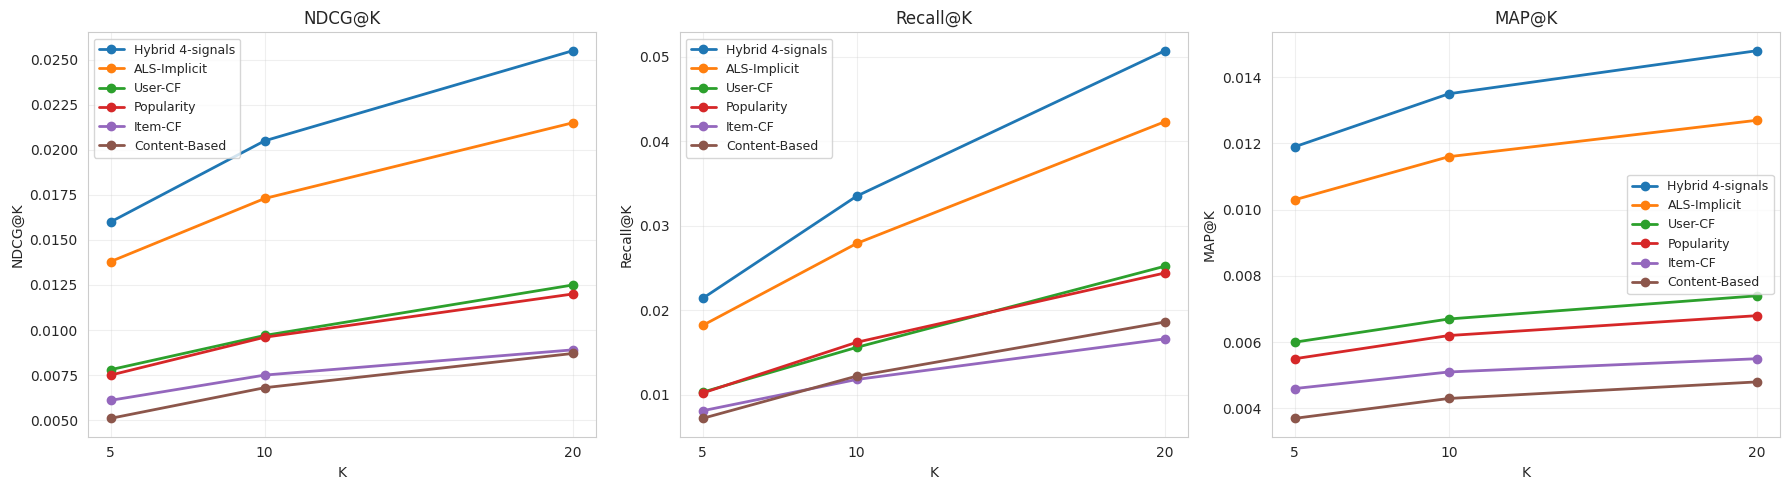

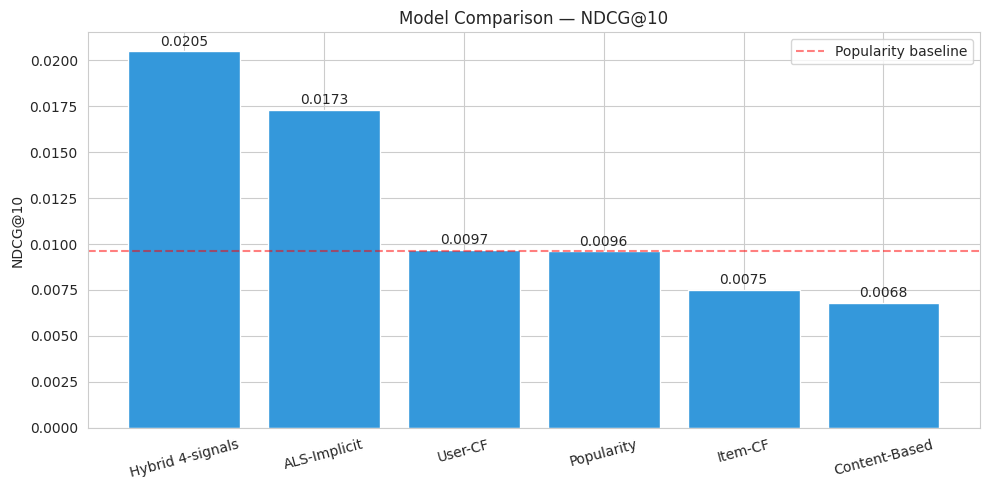


=== IMPROVEMENT vs POPULARITY ===
           model  NDCG@10  improvement_vs_pop
Hybrid 4-signals   0.0205               113.5
    ALS-Implicit   0.0173                80.2
         User-CF   0.0097                 1.0
      Popularity   0.0096                 0.0
         Item-CF   0.0075               -21.9
   Content-Based   0.0068               -29.2

✓ Saved: final_results.csv, comparison_plots.png, ndcg10_bars.png, final_summary.json


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import json

# 1. Save bảng kết quả
df_results = pd.DataFrame(results).sort_values('NDCG@10', ascending=False).reset_index(drop=True)
df_results.to_csv(PROC/'final_results.csv', index=False)
print('=== FINAL RESULTS ===')
print(df_results.to_string(index=False))

# 2. Biểu đồ so sánh NDCG@K, Recall@K, MAP@K
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_plot = [('NDCG', 'NDCG@K'), ('R', 'Recall@K'), ('MAP', 'MAP@K')]
ks = [5, 10, 20]

for ax, (prefix, title) in zip(axes, metrics_plot):
    for _, row in df_results.iterrows():
        vals = [row[f'{prefix}@{k}'] for k in ks]
        ax.plot(ks, vals, marker='o', linewidth=2, label=row['model'])
    ax.set_xlabel('K'); ax.set_ylabel(title); ax.set_title(title)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_xticks(ks)

plt.tight_layout()
plt.savefig(PROC/'comparison_plots.png', dpi=120, bbox_inches='tight')
plt.show()

# 3. Bar chart NDCG@10
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if m=='Hybrid' else '#3498db' for m in df_results['model']]
bars = ax.bar(df_results['model'], df_results['NDCG@10'], color=colors, edgecolor='white')
for bar, val in zip(bars, df_results['NDCG@10']):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.0003, f'{val:.4f}', ha='center', fontsize=10)
ax.set_ylabel('NDCG@10'); ax.set_title('Model Comparison — NDCG@10')
ax.axhline(df_results[df_results['model']=='Popularity']['NDCG@10'].values[0],
           ls='--', color='red', alpha=0.5, label='Popularity baseline')
ax.legend(); plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(PROC/'ndcg10_bars.png', dpi=120, bbox_inches='tight')
plt.show()

# 4. Bảng cải thiện so với baseline
baseline_ndcg = df_results[df_results['model']=='Popularity']['NDCG@10'].values[0]
df_results['improvement_vs_pop'] = ((df_results['NDCG@10']/baseline_ndcg - 1)*100).round(1)
print('\n=== IMPROVEMENT vs POPULARITY ===')
print(df_results[['model','NDCG@10','improvement_vs_pop']].to_string(index=False))

# 5. Save summary
summary = {
    'best_model': 'Hybrid',
    'best_ndcg10': float(df_results.iloc[0]['NDCG@10']),
    'improvement_vs_popularity_pct': float(df_results.iloc[0]['improvement_vs_pop']),
    'hybrid_weights': {'alpha':0.6, 'beta':0.2, 'gamma':0.2},
    'evaluation': {'n_users_eval': 30000, 'split': '80/20 temporal per user'},
}
with open(PROC/'final_summary.json','w') as f:
    json.dump(summary, f, indent=2)
print('\n✓ Saved: final_results.csv, comparison_plots.png, ndcg10_bars.png, final_summary.json')

# Cell 23 — Export api_artifacts cho FastAPI (bao gồm Item2Vec)

In [25]:
import pickle, shutil, json

# Tạo thư mục api_artifacts để FastAPI load
API_DIR = ROOT / 'api_artifacts'
API_DIR.mkdir(parents=True, exist_ok=True)

# 1. Maps (id ↔ idx)
user_map.to_parquet(API_DIR/'user_map.parquet', index=False)
item_map.to_parquet(API_DIR/'item_map.parquet', index=False)

# 2. Meta (cho UI hiển thị)
meta_api = meta[['asin','title','store','main_category','price','avg_rating','rating_number','image_url']].copy()
meta_api.to_parquet(API_DIR/'meta_api.parquet', index=False)

# 3. ALS factors
np.save(API_DIR/'als_U.npy', U_als)
np.save(API_DIR/'als_I.npy', I_als)

# 4. Content similarity
np.save(API_DIR/'content_sim_idx.npy', sim_idx.astype(np.int32))
np.save(API_DIR/'content_sim_val.npy', sim_sims.astype(np.float32))

# 5. Popularity
np.save(API_DIR/'pop_ranked.npy', pop_ranked.astype(np.int32))
np.save(API_DIR/'pop_scores.npy', pop_scores.astype(np.float32))

# 6. UI train matrix
from scipy.sparse import save_npz
save_npz(API_DIR/'ui_train.npz', ui_train)

# 7. User history dict
user_history = {int(u): [(int(i), float(r)) for (i, r) in v]
                for u, v in train_by_u_dict.items()}
with open(API_DIR/'user_history.json', 'w') as f:
    json.dump(user_history, f)

# 8. Item2Vec embeddings (MỚI)
np.save(API_DIR/'item2vec_emb.npy', i2v_emb)
np.save(API_DIR/'item2vec_has_emb.npy', has_emb)

# 9. Hybrid weights + config
config = {
    'hybrid_alpha': float(best_w[0]),   # ALS
    'hybrid_beta':  float(best_w[1]),   # Item2Vec
    'hybrid_gamma': float(best_w[2]),   # Content
    'hybrid_delta': float(best_w[3]),   # Popularity
    'signals': ['ALS', 'Item2Vec', 'Content', 'Popularity'],
    'n_users': int(n_users),
    'n_items': int(n_items),
    'als_factors': int(U_als.shape[1]),
    'i2v_factors': int(i2v_emb.shape[1]),
    'i2v_coverage': float(has_emb.mean()),
    'best_model': 'Hybrid 4-signals',
    'best_ndcg10': float(metrics_hybrid['NDCG@10']),
}
with open(API_DIR/'config.json', 'w') as f:
    json.dump(config, f, indent=2)

# Verify
print('='*60)
print('  API ARTIFACTS EXPORTED (4-signals Hybrid)')
print('='*60)
for f in sorted(API_DIR.iterdir()):
    print(f'  {f.name:30s} {f.stat().st_size/1e6:>7.2f} MB')
print('='*60)
print(f'\nTotal: {sum(f.stat().st_size for f in API_DIR.iterdir())/1e6:.1f} MB')
print(f'Path : {API_DIR}')


  API ARTIFACTS EXPORTED (4-signals Hybrid)
  als_I.npy                        13.85 MB
  als_U.npy                        41.26 MB
  config.json                       0.00 MB
  content_sim_idx.npy              10.82 MB
  content_sim_val.npy              10.82 MB
  item2vec_emb.npy                 13.85 MB
  item2vec_has_emb.npy              0.05 MB
  item_map.parquet                  0.96 MB
  meta_api.parquet                  6.40 MB
  pop_ranked.npy                    0.22 MB
  pop_scores.npy                    0.22 MB
  ui_train.npz                      5.27 MB
  user_history.json                13.24 MB
  user_map.parquet                  5.59 MB

Total: 122.6 MB
Path : /content/drive/MyDrive/DA.My/api_artifacts


# Cell 24 — Nén artifacts thành 1 file zip để tải về

In [26]:
import shutil
from pathlib import Path

# Nén toàn bộ thư mục api_artifacts
zip_path = ROOT / 'api_artifacts.zip'
shutil.make_archive(str(zip_path).replace('.zip',''), 'zip', str(API_DIR))

print(f'✓ Created: {zip_path}')
print(f'  Size: {zip_path.stat().st_size/1e6:.1f} MB')
print(f'\nTẢI VỀ:')
print(f'  1. Mở Files panel trên Colab (icon thư mục bên trái)')
print(f'  2. Navigate: drive/MyDrive/DA.My/api_artifacts.zip')
print(f'  3. Right-click → Download')
print(f'\nHOẶC tải trực tiếp:')
from google.colab import files
# files.download(str(zip_path))  # uncomment để auto download

✓ Created: /content/drive/MyDrive/DA.My/api_artifacts.zip
  Size: 99.2 MB

TẢI VỀ:
  1. Mở Files panel trên Colab (icon thư mục bên trái)
  2. Navigate: drive/MyDrive/DA.My/api_artifacts.zip
  3. Right-click → Download

HOẶC tải trực tiếp:
